# Projeto Final - Pré-processamento de Dados em Vendas

## Parte 2 - Transformação e Análise

Nesta etapa o projeto parte da base limpa, cria novas variáveis, normaliza atributos numéricos, gera visualizações e consolida os principais resultados analíticos de forma executiva e reprodutível.


## Continuidade da análise

Este notebook retoma a base já tratada na Parte 1 e avança para a etapa analítica. O foco deixa de ser a correção dos dados e passa a ser a geração de variáveis, a leitura visual e a interpretação executiva dos resultados.

Aqui o objetivo é transformar a base limpa em informação útil para leitura de negócio.


## Retomando a base limpa

Quando a Parte 1 já foi executada, carregamos a base tratada. Caso contrário, o notebook recompõe o pipeline a partir dos arquivos brutos para manter a execução reprodutível e o fluxo de trabalho íntegro.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

from sklearn.preprocessing import StandardScaler
from src import build_pipeline, summarize_sales

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'dados').exists() and (PROJECT_ROOT.parent / 'dados').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / 'dados' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'dados' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

arquivo_base_limpa = PROCESSED_DIR / 'base_vendas_limpa.csv'
if arquivo_base_limpa.exists():
    base_limpa = pd.read_csv(arquivo_base_limpa, parse_dates=['data_emissao'])
else:
    base_limpa, _ = build_pipeline(RAW_DIR)

print('Base limpa carregada:', base_limpa.shape)
display(base_limpa.head())


Base limpa carregada: (667, 49)


,data_emissao,id_produto_servico,id_produto_servico_empresa,tipo_transacao,direcao_estoque,cd_modelo,descricao_modelo,cd_modelo_fiscal,id_pessoa,cd_situacao,descricao_situacao,status_item_cancelado,valor_desconto_digitado,valor_desconto_proporcional,valor_frete_item,cd_cfop,descricao_cfop,qtd_item_movimentacao,qtd_venda,valor_unitario,_arquivo_origem,cd_produto_servico,descricao,status_produto_servico,pesavel,vendavel,percentual_cashback,unidade_sigla,tipo_item_descricao,sub_grupo_referencia,codigo_barras,codigo_barras_tributavel,id_produto_servico_empresa_referencia,id_empresa_referencia,id_estoque_referencia,id_preco_referencia,margem_lucro_aplicada_referencia,limite_desconto_referencia,percentual_comissao_referencia,_source_ingestion_timestamp,_source_file,flag_item_ativo,receita_bruta_item,desconto_total_item,receita_liquida_item,flag_outlier_receita,dia_semana,mes_referencia,eh_final_de_semana
0,2026-05-01,662875b00345e118a4611764,66731dde0345e118a4611790,VENDA,SAIDA,24,Nota Fiscal Consumidor Eletrônica,65,66731ddf0345e118a46131bd,2,Concluído,False,0.0,0.0,0.0,5102,Venda de mercadoria adquirida ou recebida de t...,1.592,1.592,99.9,movimentacoes_20260501.json,738,Vazio Novilho Jovem,True,True,True,0.0,Quilograma,Mercadoria para Revenda,669a6f868df90b307cb5296b,NaN,NaN,66731dde0345e118a4611790,66731a400345e149c87d17a7,66731dde0345e118a4611766,66731dde0345e118a461177a,0.0,0.0,0.0,2026-04-18 13:00:08.529953 UTC,produtos_servicos_2026-04-18_10-00-08.ndjson,True,159.0408,0.0,159.0408,False,sexta,2026-05,False
1,2026-05-01,68adf63a4211dc2f3475d917,68adf63a4211dc2f3475d91c,VENDA,SAIDA,24,Nota Fiscal Consumidor Eletrônica,65,66731ddf0345e118a46131bd,2,Concluído,False,0.0,0.0,0.0,5102,Venda de mercadoria adquirida ou recebida de t...,1.000,1.000,81.9,movimentacoes_20260501.json,1255,Camarão Rosa 500g,True,True,True,0.0,Unidade,Mercadoria para Revenda,669a6f868df90b307cb5296f,7.890018e+12,NaN,68adf63a4211dc2f3475d91c,66731a400345e149c87d17a7,68adf63a4211dc2f3475d918,68adf63a4211dc2f3475d919,0.0,0.0,0.0,2026-04-18 13:00:08.780070 UTC,produtos_servicos_2026-04-18_10-00-08.ndjson,True,81.9000,0.0,81.9000,False,sexta,2026-05,False
2,2026-05-01,6052c2300345e118a461223e,66731dde0345e118a4612268,VENDA,SAIDA,24,Nota Fiscal Consumidor Eletrônica,65,69e3e0234211dc2e8c649ed4,2,Concluído,False,0.0,0.0,0.0,5102,Venda de mercadoria adquirida ou recebida de t...,1.000,1.000,42.9,movimentacoes_20260501.json,137,Pão de alho Dos Greco 500g,True,True,True,0.0,Unidade,Mercadoria para Revenda,669a721d8df90b307cb52972,NaN,NaN,66731dde0345e118a4612268,66731a400345e149c87d17a7,66731dde0345e118a461224f,66731dde0345e118a4612265,0.0,0.0,0.0,2026-04-18 13:00:08.438872 UTC,produtos_servicos_2026-04-18_10-00-08.ndjson,True,42.9000,0.0,42.9000,False,sexta,2026-05,False
3,2026-05-01,67e456138df90b3394089f54,67e456138df90b3394089f59,VENDA,SAIDA,24,Nota Fiscal Consumidor Eletrônica,65,69e3e0234211dc2e8c649ed4,2,Concluído,False,0.0,0.0,0.0,5102,Venda de mercadoria adquirida ou recebida de t...,0.574,0.574,109.9,movimentacoes_20260501.json,1049,Entrecot FS,True,True,True,0.0,Quilograma,Mercadoria para Revenda,669a6f868df90b307cb5296b,7.890014e+12,NaN,67e456138df90b3394089f59,66731a400345e149c87d17a7,67e456138df90b3394089f55,67e456138df90b3394089f56,0.0,0.0,0.0,2026-04-18 13:00:08.689883 UTC,produtos_servicos_2026-04-18_10-00-08.ndjson,True,63.0826,0.0,63.0826,False,sexta,2026-05,False
4,2026-05-01,686428e94211dc655073d519,686428e94211dc655073d51e,VENDA,SAIDA,24,Nota Fiscal Consumidor Eletrônica,65,69e3e0234211dc2e8c649ed4,2,Concluído,False,0.0,0.0,0.0,5102,Venda de mercadoria adquirida ou recebida de t...,0.566,0.566,119.9,movimentacoes_20260501.json,1164,Denver Steak FS,True,True,True,0.0,Quilograma,Mercadoria para Revenda,669a6f868df90b307cb5296b,7.890012e+12,NaN,686428e94211dc655073d51e,66731a400345e149c87d17a7,686428e94211dc655073d51a,686428e94211dc655073d51b,0.0,0.0,0.0,2026-04-18 13:00:08.736837 UTC,produtos_servicos_2026-04-18_10-00-08.ndjson,True,67.8634,0.0,6

## Transformação dos Dados

Depois da limpeza, o projeto constrói variáveis de negócio para ampliar a leitura dos dados e permitir uma análise mais rica, conectando os atributos operacionais à interpretação gerencial.


### Engenharia de Features

Aqui o projeto cria métricas que fazem sentido para vendas: receita bruta, desconto total, receita líquida e percentual de desconto. Essas variáveis sintetizam o comportamento da transação e ajudam a explicar o valor gerado em cada item.


In [2]:
df_base = base_limpa.copy()
df_base['receita_bruta_item'] = df_base['qtd_venda'] * df_base['valor_unitario']
df_base['desconto_total_item'] = df_base[['valor_desconto_digitado', 'valor_desconto_proporcional']].fillna(0).sum(axis=1)
df_base['receita_liquida_item'] = df_base['receita_bruta_item'] - df_base['desconto_total_item'] + df_base['valor_frete_item'].fillna(0)
df_base['percentual_desconto_item'] = np.where(df_base['receita_bruta_item'] > 0, (df_base['desconto_total_item'] / df_base['receita_bruta_item']) * 100, 0)
df_base['tem_desconto'] = df_base['desconto_total_item'] > 0
df_base['faixa_ticket'] = pd.cut(df_base['receita_liquida_item'], bins=[-np.inf, 0, 50, 100, np.inf], labels=['sem_receita', 'baixa', 'media', 'alta'])

display(df_base[["descricao", "receita_bruta_item", "desconto_total_item", "receita_liquida_item", "percentual_desconto_item"]].head())


,descricao,receita_bruta_item,desconto_total_item,receita_liquida_item,percentual_desconto_item
0,Vazio Novilho Jovem,159.0408,0.0,159.0408,0.0
1,Camarão Rosa 500g,81.9000,0.0,81.9000,0.0
2,Pão de alho Dos Greco 500g,42.9000,0.0,42.9000,0.0
3,Entrecot FS,63.0826,0.0,63.0826,0.0
4,Denver Steak FS,67.8634,0.0,67.8634,0.0


### Categorização e Normalização

Na sequência, o projeto codifica variáveis categóricas e padroniza colunas numéricas. Esse passo é importante porque a base passa a ficar apta para análises e modelos sensíveis à escala das variáveis, além de facilitar comparações entre atributos com magnitudes distintas.


In [3]:
df_base['dia_semana'] = df_base['data_emissao'].dt.dayofweek.map({0:'segunda',1:'terca',2:'quarta',3:'quinta',4:'sexta',5:'sabado',6:'domingo'})
df_base['mes_referencia'] = df_base['data_emissao'].dt.strftime('%Y-%m')
df_base['eh_final_de_semana'] = df_base['dia_semana'].isin(['sabado', 'domingo'])

colunas_categoricas = ['tipo_item_descricao', 'unidade_sigla', 'dia_semana', 'faixa_ticket']
base_modelagem = pd.get_dummies(df_base, columns=colunas_categoricas, drop_first=True)

colunas_norm = ['qtd_venda', 'valor_unitario', 'receita_bruta_item', 'receita_liquida_item', 'percentual_desconto_item']
scaler = StandardScaler()
base_modelagem[[f'{col}_z' for col in colunas_norm]] = scaler.fit_transform(base_modelagem[colunas_norm])

print('Base de modelagem:', base_modelagem.shape)
display(base_modelagem.head())


Base de modelagem: (667, 64)


,data_emissao,id_produto_servico,id_produto_servico_empresa,tipo_transacao,direcao_estoque,cd_modelo,descricao_modelo,cd_modelo_fiscal,id_pessoa,cd_situacao,descricao_situacao,status_item_cancelado,valor_desconto_digitado,valor_desconto_proporcional,valor_frete_item,cd_cfop,descricao_cfop,qtd_item_movimentacao,qtd_venda,valor_unitario,_arquivo_origem,cd_produto_servico,descricao,status_produto_servico,pesavel,vendavel,percentual_cashback,sub_grupo_referencia,codigo_barras,codigo_barras_tributavel,id_produto_servico_empresa_referencia,id_empresa_referencia,id_estoque_referencia,id_preco_referencia,margem_lucro_aplicada_referencia,limite_desconto_referencia,percentual_comissao_referencia,_source_ingestion_timestamp,_source_file,flag_item_ativo,receita_bruta_item,desconto_total_item,receita_liquida_item,flag_outlier_receita,mes_referencia,eh_final_de_semana,percentual_desconto_item,tem_desconto,unidade_sigla_Quilograma,unidade_sigla_Unidade,dia_semana_quarta,dia_semana_quinta,dia_semana_sabado,dia_semana_segunda,dia_semana_sexta,dia_semana_terca,faixa_ticket_baixa,faixa_ticket_media,faixa_ticket_alta,qtd_venda_z,valor_unitario_z,receita_bruta_item_z,receita_liquida_item_z,percentual_desconto_item_z
0,2026-05-01,662875b00345e118a4611764,66731dde0345e118a4611790,VENDA,SAIDA,24,Nota Fiscal Consumidor Eletrônica,65,66731ddf0345e118a46131bd,2,Concluído,False,0.0,0.0,0.0,5102,Venda de mercadoria adquirida ou recebida de t...,1.592,1.592,99.9,movimentacoes_20260501.json,738,Vazio Novilho Jovem,True,True,True,0.0,669a6f868df90b307cb5296b,NaN,NaN,66731dde0345e118a4611790,66731a400345e149c87d17a7,66731dde0345e118a4611766,66731dde0345e118a461177a,0.0,0.0,0.0,2026-04-18 13:00:08.529953 UTC,produtos_servicos_2026-04-18_10-00-08.ndjson,True,159.0408,0.0,159.0408,False,2026-05,False,0.0,False,True,False,False,False,False,False,True,False,False,False,True,0.340123,0.649443,0.602935,0.680592,-0.27525
1,2026-05-01,68adf63a4211dc2f3475d917,68adf63a4211dc2f3475d91c,VENDA,SAIDA,24,Nota Fiscal Consumidor Eletrônica,65,66731ddf0345e118a46131bd,2,Concluído,False,0.0,0.0,0.0,5102,Venda de mercadoria adquirida ou recebida de t...,1.000,1.000,81.9,movimentacoes_20260501.json,1255,Camarão Rosa 500g,True,True,True,0.0,669a6f868df90b307cb5296f,7.890018e+12,NaN,68adf63a4211dc2f3475d91c,66731a400345e149c87d17a7,68adf63a4211dc2f3475d918,68adf63a4211dc2f3475d919,0.0,0.0,0.0,2026-04-18 13:00:08.780070 UTC,produtos_servicos_2026-04-18_10-00-08.ndjson,True,81.9000,0.0,81.9000,False,2026-05,False,0.0,False,False,True,False,False,False,False,True,False,False,True,False,-0.135873,0.222650,-0.009876,0.004759,-0.27525
2,2026-05-01,6052c2300345e118a461223e,66731dde0345e118a4612268,VENDA,SAIDA,24,Nota Fiscal Consumidor Eletrônica,65,69e3e0234211dc2e8c649ed4,2,Concluído,False,0.0,0.0,0.0,5102,Venda de mercadoria adquirida ou recebida de t...,1.000,1.000,42.9,movimentacoes_20260501.json,137,Pão de alho Dos Greco 500g,True,True,True,0.0,669a721d8df90b307cb52972,NaN,NaN,66731dde0345e118a4612268,66731a400345e149c87d17a7,66731dde0345e118a461224f,66731dde0345e118a4612265,0.0,0.0,0.0,2026-04-18 13:00:08.438872 UTC,produtos_servicos_2026-04-18_10-00-08.ndjson,True,42.9000,0.0,42.9000,False,2026-05,False,0.0,False,False,True,False,False,False,False,True,False,True,False,False,-0.135873,-0.702066,-0.319694,-0.336921,-0.27525
3,2026-05-01,67e456138df90b3394089f54,67e456138df90b3394089f59,VENDA,SAIDA,24,Nota Fiscal Consumidor Eletrônica,65,69e3e0234211dc2e8c649ed4,2,Concluído,False,0.0,0.0,0.0,5102,Venda de mercadoria adquirida ou recebida de t...,0.574,0.574,109.9,movimentacoes_20260501.json,1049,Entrecot FS,True,True,True,0.0,669a6f868df90b307cb5296b,7.890014e+12,NaN,67e456138df90b3394089f59,66731a400345e149c87d17a7,67e456138df90b3394089f55,67e456138df90b3394089f56,0.0,0.0,0.0,2026-04-18 13:00:08.689883 UTC,produtos_servicos_2026-04-18_10-00-08.ndjson,True,63.0826,0.0,63.0826,False,2026-05,False,0.0,False,True,False,False,False,False,False,True,False,False,True,False,-0.478397,0.8865

### Visualização dos Dados

As visualizações ajudam a interpretar rapidamente a dispersão da receita e a concentração dos valores. Em um projeto de pós-graduação, esse tipo de leitura visual precisa vir acompanhado de interpretação de negócio e de síntese executiva.


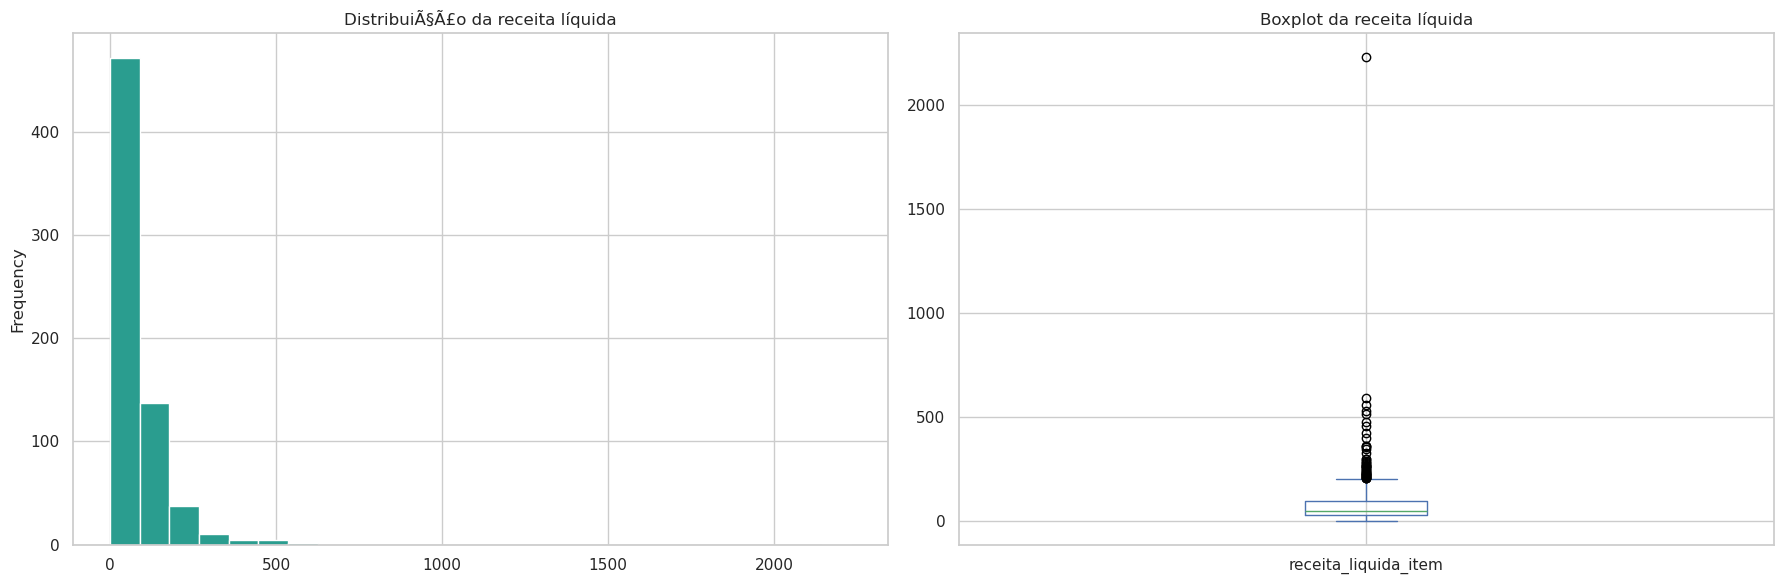

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
df_base['receita_liquida_item'].plot(kind='hist', bins=25, ax=ax[0], color='#2a9d8f', title='DistribuiÃ§Ã£o da receita líquida')
df_base['receita_liquida_item'].plot(kind='box', ax=ax[1], title='Boxplot da receita líquida')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distribuicao_receita_liquida.png', dpi=150, bbox_inches='tight')
plt.show()


### Leitura executiva dos indicadores

Os resultados mostram um cenário de receita concentrada e com assimetria positiva. Isso significa que alguns itens de maior valor influenciam mais o total da operação do que a média isoladamente sugere.

Além disso, a presença de descontos, a concentração em final de semana e os outliers de receita ajudam a contar uma história mais completa sobre o comportamento das vendas.


## Resumo Executivo dos Resultados

A base tratada consolidou **667 registros válidos**, cobrindo o período de **2026-05-01 a 2026-05-12**.

Principais números do projeto:
- **Receita líquida total:** 54.264,98
- **Receita líquida média por item:** 81,36
- **Receita líquida mediana por item:** 50,00
- **Itens com desconto:** 109 registros
- **Desconto médio por item:** 1,66%
- **Outliers de receita detectados pelo IQR:** 46 registros (6,9%)
- **Participação de vendas em final de semana:** 67,02%

A receita está fortemente concentrada em poucos produtos, com destaque para **Entrecot FS**, **Assado Tiras FS** e **Espumante Cave Amadeu Brut Rosé**.

Do ponto de vista analítico, a base é composta exclusivamente por **Mercadoria para Revenda**, o que reforça a coerência do recorte do projeto.


### Interpretação dos Resultados

Os números mostram um comportamento comercial bastante concentrado. A receita líquida total ficou em **54.264,98**, mas a mediana por item foi de **50,00**, enquanto a média ficou em **81,36**. Essa diferença entre média e mediana sugere assimetria positiva, isto é, alguns itens de maior valor estão puxando o resultado total para cima.

A presença de **46 outliers de receita** pelo critério do IQR reforça que existem transações com valor acima da faixa esperada. Em um cenário corporativo, isso não significa erro automaticamente: pode refletir itens premium, compras maiores ou efeitos sazonais. Por isso, a marcação de outliers foi tratada como sinal analítico, e não como descarte automático.

Outro ponto relevante é a participação de **67,02% das vendas em final de semana**, indicando que o comportamento temporal merece atenção e pode ser explorado em análises de calendário, campanhas e escala operacional.


### Concentração de Receita

O ranking de produtos mostra forte concentração em poucos itens, com destaque para **Entrecot FS**, **Assado Tiras FS** e **Espumante Cave Amadeu Brut Rosé**. Esse padrão é importante porque sinaliza dependência de poucos produtos de alto valor, o que pode influenciar decisões de estoque, exposição comercial e estratégia de precificação.

Além disso, a base final é composta exclusivamente por **Mercadoria para Revenda**, o que confirma coerência com o recorte de vendas adotado no projeto e mantém o foco analítico bem alinhado ao negócio.


,descricao,receita_liquida_item
49,Entrecot FS,3524.1436
1,Assado Tiras FS,3014.3608
58,Espumante Cave Amadeu Brut Rosé,2232.0000
136,Vazio Novilho Jovem,2171.7762
135,Vazio Las Piedras Family Selection,2053.4194
36,Costela do Traseiro FS,1966.6709
107,Picanha Fazenda Cristal,1734.2616
93,Matambre Grill suíno,1628.3274
71,Flat Iron Boisul,1580.4462
105,Picanha Brasaria,1435.4372


,tipo_item_descricao,receita_liquida_item
0,Mercadoria para Revenda,54264.98334


,data_emissao,receita_liquida_item
0,2026-05-01,2856.39802
1,2026-05-02,3869.08620
2,2026-05-03,5238.41720
3,2026-05-05,914.43340
4,2026-05-06,3956.41980


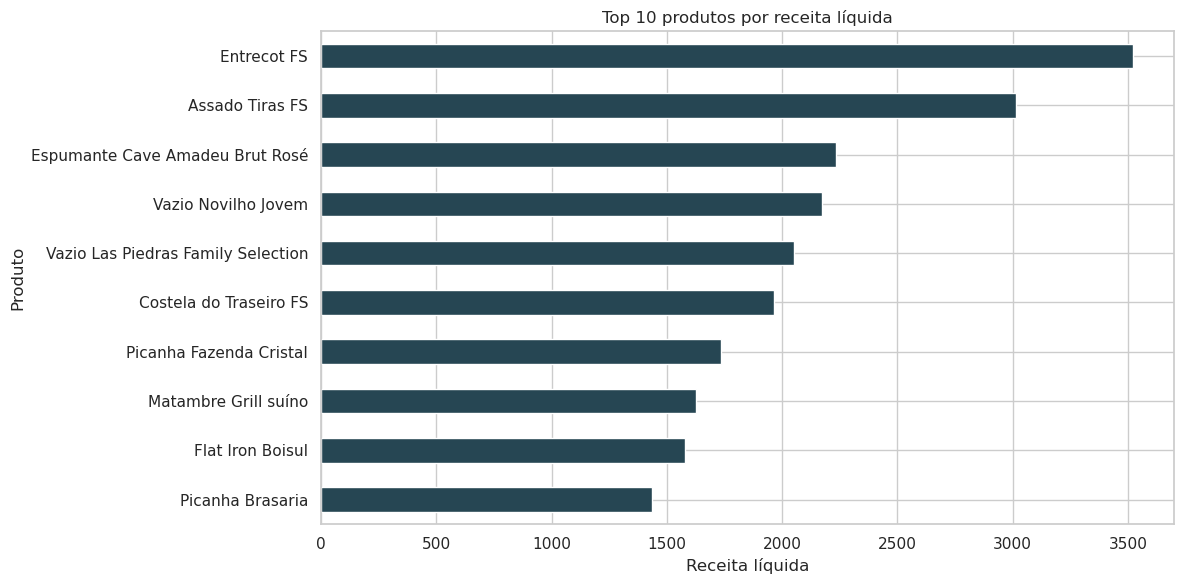

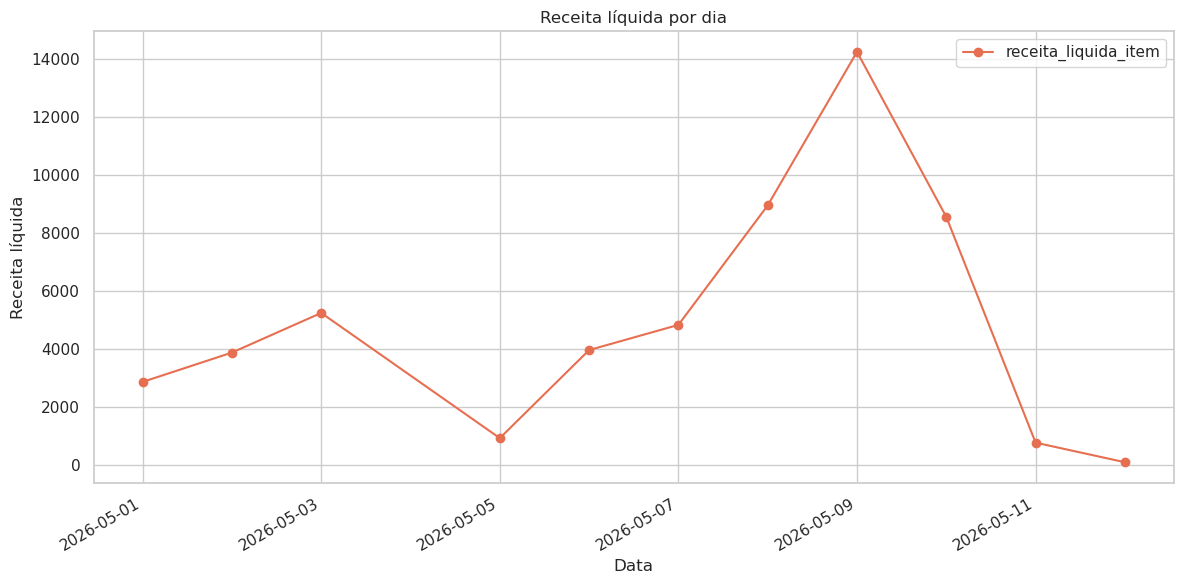

In [5]:
summary = summarize_sales(df_base)

display(summary['top_products'])
display(summary['revenue_by_category'])
display(summary['revenue_by_day'].head())

ax = summary['top_products'].sort_values('receita_liquida_item').plot(kind='barh', x='descricao', y='receita_liquida_item', legend=False, color='#264653')
ax.set_title('Top 10 produtos por receita líquida')
ax.set_xlabel('Receita líquida')
ax.set_ylabel('Produto')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_10_produtos_receita.png', dpi=150, bbox_inches='tight')
plt.show()

ax = summary['revenue_by_day'].plot(x='data_emissao', y='receita_liquida_item', marker='o', color='#e76f51')
ax.set_title('Receita líquida por dia')
ax.set_xlabel('Data')
ax.set_ylabel('Receita líquida')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'receita_por_dia.png', dpi=150, bbox_inches='tight')
plt.show()


### Consolidação da entrega

Os resultados finais são salvos em CSV para garantir reprodutibilidade e permitir o uso posterior em outras análises ou modelagens.


In [6]:
saida_base = PROCESSED_DIR / 'base_vendas_tratada.csv'
saida_modelagem = PROCESSED_DIR / 'base_vendas_modelagem.csv'

df_base.to_csv(saida_base, index=False)
base_modelagem.to_csv(saida_modelagem, index=False)

print('Base tratada salva em:', saida_base)
print('Base para modelagem salva em:', saida_modelagem)


Base tratada salva em: /workspace/dados/processed/base_vendas_tratada.csv
Base para modelagem salva em: /workspace/dados/processed/base_vendas_modelagem.csv


### Próximos usos da base

Depois desta etapa, a base fica pronta para usos mais avançados, como segmentação de produtos, análise temporal mais detalhada e até preparação para modelos preditivos futuros.

Ou seja, o projeto não termina na limpeza: ele deixa uma estrutura organizada para continuidade de análise e tomada de decisão.


## Conclusão

Com isso, o projeto fecha o pipeline: a base foi limpa, enriquecida com novas features, padronizada e resumida em gráficos e tabelas que ajudam a contar a história do negócio.

O resultado final está alinhado com a proposta da disciplina: transformar dados brutos em informação confiável e pronta para análise. Do ponto de vista executivo, a base final reúne **667 registros**, **143 produtos distintos**, uma receita líquida total de **54.264,98** e um perfil de vendas com forte presença em finais de semana, o que já aponta caminhos concretos para análises futuras.
